<a href="https://colab.research.google.com/github/tejalkv0/GAN/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.92MB/s]


Epoch 1 | D loss 0.041 | G loss 5.693


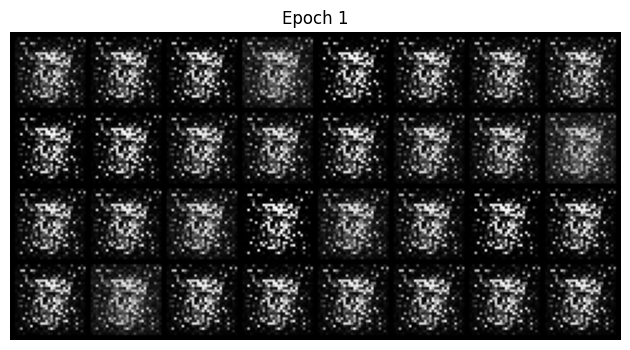

Epoch 10 | D loss 0.148 | G loss 5.564


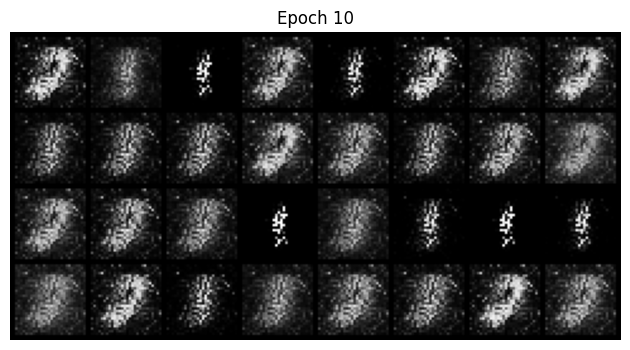

Epoch 20 | D loss 0.089 | G loss 6.841


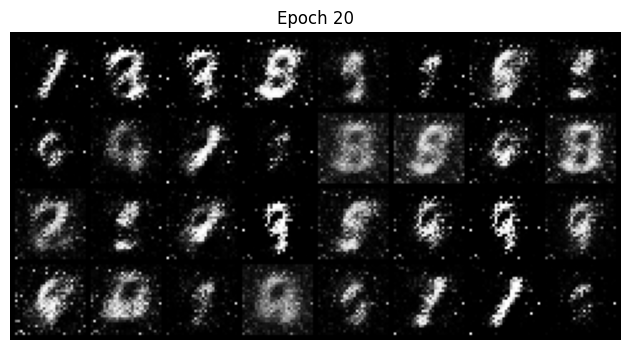

Epoch 30 | D loss 0.317 | G loss 4.420


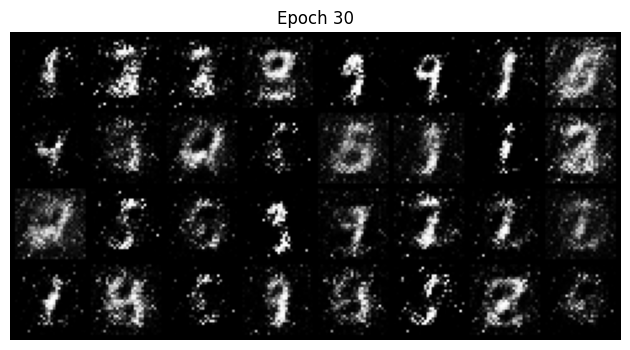

In [ ]:
# Mini GAN - generates handwritten digits (PyTorch) - Google Colab GPU
# Runtime > Change runtime type > T4 GPU

import torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", dev)

tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
data = DataLoader(datasets.MNIST("data", download=True, transform=tf),
                  batch_size=128, shuffle=True, drop_last=True)

nz = 64
G = nn.Sequential(nn.Linear(nz, 256), nn.ReLU(), nn.Linear(256, 512), nn.ReLU(),
                  nn.Linear(512, 784), nn.Tanh()).to(dev)
D = nn.Sequential(nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Linear(512, 256),
                  nn.LeakyReLU(0.2), nn.Linear(256, 1)).to(dev)

loss = nn.BCEWithLogitsLoss()
oG = torch.optim.Adam(G.parameters(), 2e-4)
oD = torch.optim.Adam(D.parameters(), 2e-4)
fixed = torch.randn(32, nz, device=dev)

def show(ep):
    with torch.no_grad():
        img = G(fixed).view(-1, 1, 28, 28).cpu()
    plt.figure(figsize=(8, 4)); plt.axis("off"); plt.title(f"Epoch {ep}")
    plt.imshow(make_grid(img, nrow=8, normalize=True).permute(1, 2, 0)); plt.show()

for ep in range(1, 31):
    for x, _ in data:
        x = x.view(-1, 784).to(dev); n = len(x)
        ones, zeros = torch.ones(n, 1, device=dev), torch.zeros(n, 1, device=dev)

        fake = G(torch.randn(n, nz, device=dev))
        lD = loss(D(x), ones) + loss(D(fake.detach()), zeros)   # train discriminator
        oD.zero_grad(); lD.backward(); oD.step()

        lG = loss(D(fake), ones)                                # train generator
        oG.zero_grad(); lG.backward(); oG.step()

    if ep in (1, 10, 20, 30):
        print(f"Epoch {ep} | D loss {lD.item():.3f} | G loss {lG.item():.3f}")
        show(ep)